In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
os.chdir('../')

LABELS = [
    ("hse-gs", "defect_spin_state", "4.0")
]

NAMES = [
    "Spin State"
]

NAMES = NAMES[::-1]

In [4]:
import torch
import GCN_classifier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.utils import dense_to_sparse
from torch_geometric.data import Data
from sklearn.metrics import confusion_matrix, classification_report
import importlib
#importlib.reload(GCN_classifier)

def plot_confusion_matrix(label1, label2, version, title, save=False):
    if not os.path.exists(f'filtered_data/{label1}_{label2}_X_val.npy'):
        raise FileNotFoundError(f"Label not found")

    if save:
        folder_path = f'pictures/{label1}_{label2}'
        os.makedirs(folder_path, exist_ok=True)

    types = ['val', 'train']
    
    # Load classes
    classes = np.load(f'filtered_data/{label1}_{label2}_classes.npy')
    num_classes = len(classes)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle(f'{title} Confusion Matrix', fontsize=28, fontweight='bold', color='#2C3E50')

    for index, t_val in enumerate(types):
        # Load validation data
        data_x = np.load(f'filtered_data/{label1}_{label2}_X_{t_val}.npy')
        data_adj = np.load(f'filtered_data/{label1}_{label2}_adj_{t_val}.npy')
        data_y = np.load(f'filtered_data/{label1}_{label2}_y_{t_val}.npy')

        # Convert to tensors
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
        X_tensor = torch.tensor(data_x, dtype=torch.float).to(device)
        adj_tensor = torch.tensor(data_adj, dtype=torch.float).to(device)
        y_tensor = torch.tensor(data_y, dtype=torch.long).to(device)

        model = GCN_classifier.GraphConvClassifier(20, num_classes, 0.001).to(device)
        model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_location=device))
        model.eval()

        # Prepare graphs
        graphs = []
        for i in range(len(X_tensor)):
            edge_index, _ = dense_to_sparse(adj_tensor[i, :GCN_classifier.GRAPH_SIZE, :GCN_classifier.GRAPH_SIZE])
            data = Data(x=X_tensor[i, :GCN_classifier.GRAPH_SIZE], edge_index=edge_index)
            graphs.append(data)

        # Predict
        preds = []
        with torch.no_grad():
            for data in graphs:
                x = data.x
                edge_index = data.edge_index
                batch = torch.zeros(x.size(0), dtype=torch.long, device=device)
                pred = model(x, data.edge_index, data.edge_weight, batch)
                pred_class = torch.argmax(pred, dim=1).cpu().numpy()
                preds.append(pred_class[0])

        preds = np.array(preds)
        y_true = y_tensor.cpu().numpy().flatten()

        # Confusion matrix
        cm = confusion_matrix(y_true, preds, labels=np.arange(num_classes))

        ax = axes[index]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                    xticklabels=classes, yticklabels=classes, cbar=False)
        
        ax.set_xlabel('Predicted', fontsize=20, fontweight='bold', color='#2C3E50')
        ax.set_ylabel('Actual', fontsize=20, fontweight='bold', color='#2C3E50')
        
        if index == 0:
            ax.set_title('Testing Data', fontsize=24, fontweight='bold', color='#2C3E50', pad=15)
        else:
            ax.set_title('Training Data', fontsize=24, fontweight='bold', color='#2C3E50', pad=15)
        
        # Styling
        ax.tick_params(axis='both', labelsize=16, colors='#2C3E50')
        for spine in ax.spines.values():
            spine.set_edgecolor('#2C3E50')
            spine.set_linewidth(2)
        ax.set_facecolor('#FAFAFA')

    fig.patch.set_facecolor('white')
    plt.tight_layout()
    if save:
        plt.savefig(f'pictures/{label1}_{label2}/confusion_{version}.png', dpi=300, bbox_inches='tight', facecolor='white')
        plt.savefig(f'pictures/{label1}_{label2}/confusion_{version}.svg', bbox_inches='tight')

    plt.show()

    # Print classification report for val
    print(f"Classification Report for {title} (Validation):")
    print(classification_report(y_true, preds, target_names=classes))

/tmp/ipykernel_4404/1915353386.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_loc

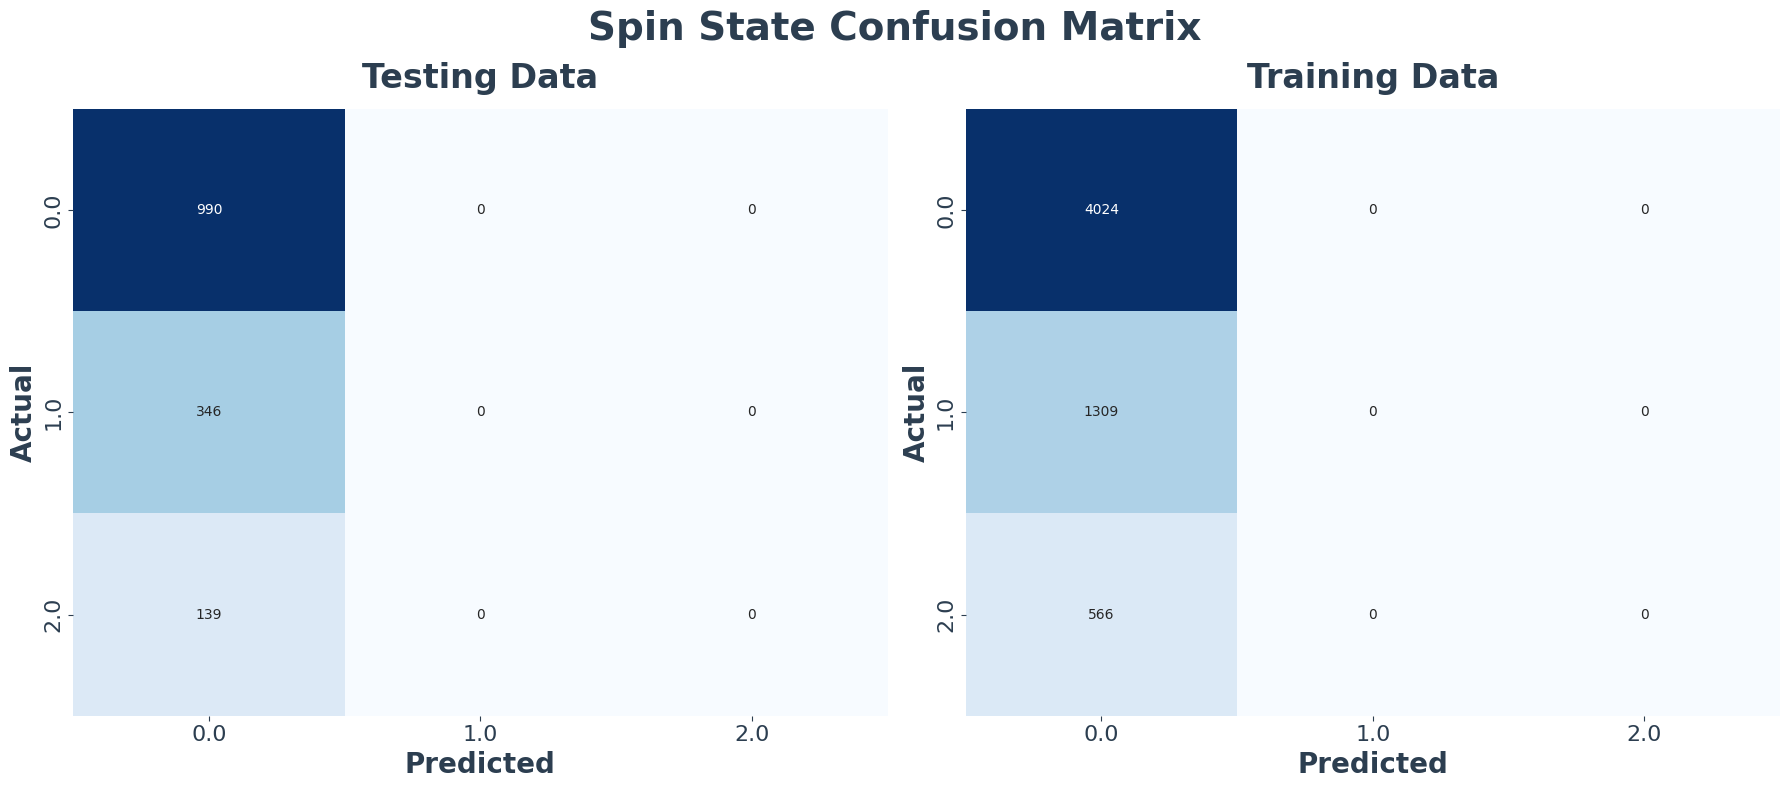

Classification Report for Spin State (Validation):


/home/petedowney/miniconda3/envs/MLQuanta/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


TypeError: object of type 'numpy.float64' has no len()

In [7]:
for label, name in zip(LABELS, NAMES):
    plot_confusion_matrix(label[0], label[1], label[2], name, save=True)

In [2]:
# Load and print the classes
classes = np.load('filtered_data/hse-gs_defect_spin_state_classes.npy')
print("Classes:", classes)


Classes: [0. 1. 2.]
